In [98]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

# machine learning
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC, LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import Perceptron
from sklearn.linear_model import SGDClassifier
from sklearn.tree import DecisionTreeClassifier

In [99]:
#loading csv file

train_df = pd.read_csv('train_1.csv')
test_df = pd.read_csv('test_1.csv')

In [100]:
train_df2=train_df

In [101]:
train_df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [102]:
test_df

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
413,1305,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


In [103]:
train_df = train_df.drop(['Age','Fare'], axis=1)
test_df = test_df.drop(['Age','Fare'], axis=1)
combine = [train_df, test_df]

In [104]:
combine

[     PassengerId  Survived  Pclass  \
 0              1         0       3   
 1              2         1       1   
 2              3         1       3   
 3              4         1       1   
 4              5         0       3   
 ..           ...       ...     ...   
 886          887         0       2   
 887          888         1       1   
 888          889         0       3   
 889          890         1       1   
 890          891         0       3   
 
                                                   Name     Sex  SibSp  Parch  \
 0                              Braund, Mr. Owen Harris    male      1      0   
 1    Cumings, Mrs. John Bradley (Florence Briggs Th...  female      1      0   
 2                               Heikkinen, Miss. Laina  female      0      0   
 3         Futrelle, Mrs. Jacques Heath (Lily May Peel)  female      1      0   
 4                             Allen, Mr. William Henry    male      0      0   
 ..                                         

In [105]:
for df in combine:
    df['Name_re'] = df.Name.str.extract(' ([A-Za-z]+).', expand=True)

In [106]:
pd.crosstab(train_df['Name_re'],train_df['Sex'])

Sex,female,male
Name_re,,
Billiard,0,1
Capt,0,1
Carlo,0,1
Col,0,2
Cruyssen,0,1
Don,0,1
Dr,1,6
Gordon,1,1
Impe,2,1


In [107]:
for df in combine:
    df['Name_re'] = df['Name_re'].replace(['Lady','Countess','Col','Don','Dr','Major','Rev','Sir','Jonkheer','Dona'],'Rare')
    df['Name_re'] = df['Name_re'].replace('Mlle','Miss')
    df['Name_re'] = df['Name_re'].replace('Ms','Miss')
    df['Name_re'] = df['Name_re'].replace('Mme','Miss')

In [108]:
combine

[     PassengerId  Survived  Pclass  \
 0              1         0       3   
 1              2         1       1   
 2              3         1       3   
 3              4         1       1   
 4              5         0       3   
 ..           ...       ...     ...   
 886          887         0       2   
 887          888         1       1   
 888          889         0       3   
 889          890         1       1   
 890          891         0       3   
 
                                                   Name     Sex  SibSp  Parch  \
 0                              Braund, Mr. Owen Harris    male      1      0   
 1    Cumings, Mrs. John Bradley (Florence Briggs Th...  female      1      0   
 2                               Heikkinen, Miss. Laina  female      0      0   
 3         Futrelle, Mrs. Jacques Heath (Lily May Peel)  female      1      0   
 4                             Allen, Mr. William Henry    male      0      0   
 ..                                         

In [109]:
train_df[['Name_re','Survived']].groupby(['Name_re'],as_index=False).mean()

,Name_re,Survived
0,Billiard,0.000000
1,Capt,0.000000
2,Carlo,0.000000
3,Cruyssen,0.000000
4,Gordon,1.000000
5,Impe,0.000000
6,Master,0.575000
7,Melkebeke,0.000000
8,Messemaeker,1.000000
9,Miss,0.710383


In [110]:
train_df

,PassengerId,Survived,Pclass,Name,Sex,SibSp,Parch,Ticket,Cabin,Embarked,Name_re
0,1,0,3,"Braund, Mr. Owen Harris",male,1,0,A/5 21171,NaN,S,Mr
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,1,0,PC 17599,C85,C,Mrs
2,3,1,3,"Heikkinen, Miss. Laina",female,0,0,STON/O2. 3101282,NaN,S,Miss
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,1,0,113803,C123,S,Mrs
4,5,0,3,"Allen, Mr. William Henry",male,0,0,373450,NaN,S,Mr
...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,0,0,211536,NaN,S,Rare
887,888,1,1,"Graham, Miss. Margaret Edith",female,0,0,112053,B42,S,Miss
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,1,2,W./C. 6607,NaN,S,Miss
889,890,1,1,"Behr, Mr. Karl Howell",male,0,0,111369,C148,C,Mr


In [111]:
name_re = {'Mr':1, 'Miss':2, 'Mrs':3, 'Master':4}

for df in combine:
    df['Name_re'] = df['Name_re'].map(name_re)
    df['Name_re'] = df['Name_re'].fillna(0)
    

In [112]:
train_df

,PassengerId,Survived,Pclass,Name,Sex,SibSp,Parch,Ticket,Cabin,Embarked,Name_re
0,1,0,3,"Braund, Mr. Owen Harris",male,1,0,A/5 21171,NaN,S,1.0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,1,0,PC 17599,C85,C,3.0
2,3,1,3,"Heikkinen, Miss. Laina",female,0,0,STON/O2. 3101282,NaN,S,2.0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,1,0,113803,C123,S,3.0
4,5,0,3,"Allen, Mr. William Henry",male,0,0,373450,NaN,S,1.0
...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,0,0,211536,NaN,S,0.0
887,888,1,1,"Graham, Miss. Margaret Edith",female,0,0,112053,B42,S,2.0
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,1,2,W./C. 6607,NaN,S,2.0
889,890,1,1,"Behr, Mr. Karl Howell",male,0,0,111369,C148,C,1.0


In [113]:
train_df = train_df.drop(['Name','PassengerId'], axis=1)
test_df = test_df.drop(['Name'], axis=1)
combine = [train_df, test_df]

In [114]:
combine

[     Survived  Pclass     Sex  SibSp  Parch            Ticket Cabin Embarked  \
 0           0       3    male      1      0         A/5 21171   NaN        S   
 1           1       1  female      1      0          PC 17599   C85        C   
 2           1       3  female      0      0  STON/O2. 3101282   NaN        S   
 3           1       1  female      1      0            113803  C123        S   
 4           0       3    male      0      0            373450   NaN        S   
 ..        ...     ...     ...    ...    ...               ...   ...      ...   
 886         0       2    male      0      0            211536   NaN        S   
 887         1       1  female      0      0            112053   B42        S   
 888         0       3  female      1      2        W./C. 6607   NaN        S   
 889         1       1    male      0      0            111369  C148        C   
 890         0       3    male      0      0            370376   NaN        Q   
 
      Name_re  
 0        

In [115]:
for df in combine:
    df['Sex'] = df['Sex'].map({'female':1, 'male':0}).astype(int)

In [116]:
train_df.isna().sum()

Survived      0
Pclass        0
Sex           0
SibSp         0
Parch         0
Ticket        0
Cabin       687
Embarked      2
Name_re       0
dtype: int64

In [138]:
train_df2

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


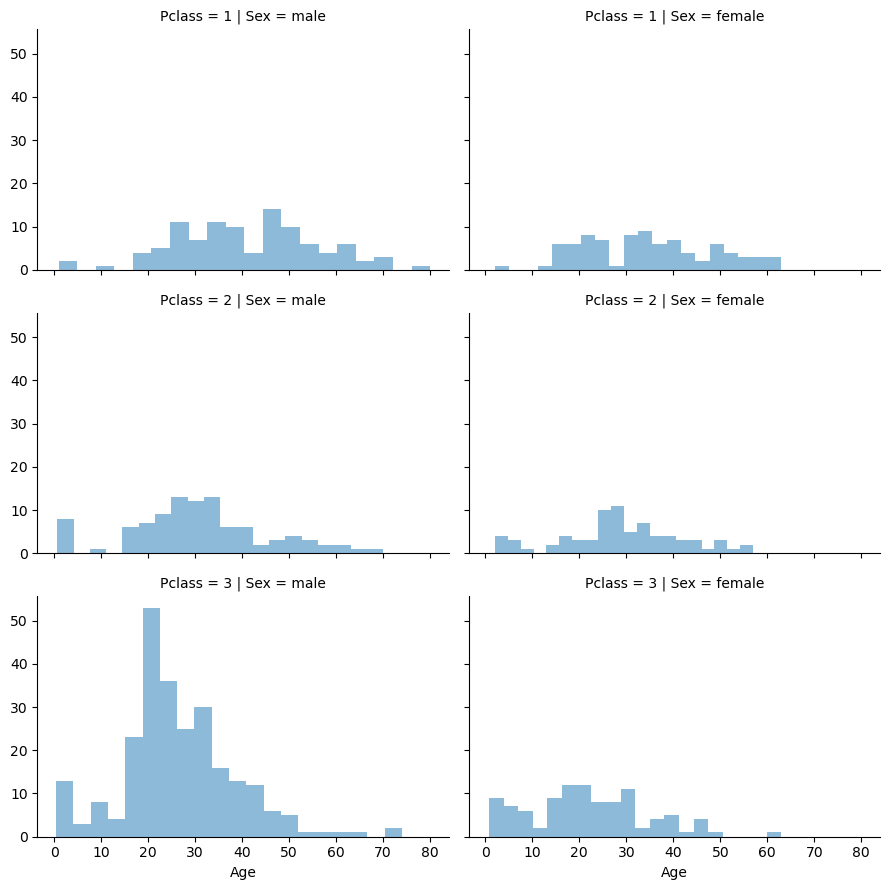

In [140]:
grid = sns.FacetGrid(train_df2, row='Pclass', col='Sex', aspect =1.5)
grid.map(plt.hist, 'Age', alpha=.5, bins=20)

In [147]:
for dataset in combine:
    dataset['FamilySize'] = dataset['SibSp'] + dataset['Parch'] +1

In [149]:
combine

[     Survived  Pclass  Sex  SibSp  Parch            Ticket Cabin Embarked  \
 0           0       3    0      1      0         A/5 21171   NaN        S   
 1           1       1    1      1      0          PC 17599   C85        C   
 2           1       3    1      0      0  STON/O2. 3101282   NaN        S   
 3           1       1    1      1      0            113803  C123        S   
 4           0       3    0      0      0            373450   NaN        S   
 ..        ...     ...  ...    ...    ...               ...   ...      ...   
 886         0       2    0      0      0            211536   NaN        S   
 887         1       1    1      0      0            112053   B42        S   
 888         0       3    1      1      2        W./C. 6607   NaN        S   
 889         1       1    0      0      0            111369  C148        C   
 890         0       3    0      0      0            370376   NaN        Q   
 
      Name_re  FamilySize  
 0        1.0           2  
 1    

In [153]:
#making dataset with columns 'familysize' and 'survived'
#organizing 'familysize' first and 'survived' after that

for dataset in combine:
    dataset['FamilySize'] = dataset['SibSp'] + dataset['Parch'] +1

combine[0][['FamilySize','Survived']].groupby(['FamilySize'],as_index=False).mean().sort_values(by='Survived',ascending=False)

,FamilySize,Survived
3,4,0.724138
2,3,0.578431
1,2,0.552795
6,7,0.333333
0,1,0.303538
4,5,0.200000
5,6,0.136364
7,8,0.000000
8,11,0.000000


In [159]:
#making new column 'isalone'

for dataset in combine:
    dataset['IsAlone'] =0
    dataset.loc[dataset['FamilySize']==1 , 'IsAlone'] =1

In [161]:
combine[0][['IsAlone','Survived']].groupby(['IsAlone'], as_index=False).mean()

,IsAlone,Survived
0,0,0.505650
1,1,0.303538


In [163]:
combine

[     Survived  Pclass  Sex  SibSp  Parch            Ticket Cabin Embarked  \
 0           0       3    0      1      0         A/5 21171   NaN        S   
 1           1       1    1      1      0          PC 17599   C85        C   
 2           1       3    1      0      0  STON/O2. 3101282   NaN        S   
 3           1       1    1      1      0            113803  C123        S   
 4           0       3    0      0      0            373450   NaN        S   
 ..        ...     ...  ...    ...    ...               ...   ...      ...   
 886         0       2    0      0      0            211536   NaN        S   
 887         1       1    1      0      0            112053   B42        S   
 888         0       3    1      1      2        W./C. 6607   NaN        S   
 889         1       1    0      0      0            111369  C148        C   
 890         0       3    0      0      0            370376   NaN        Q   
 
      Name_re  FamilySize  IsAlone  
 0        1.0           2

In [165]:
combine[1]

,PassengerId,Pclass,Sex,SibSp,Parch,Ticket,Cabin,Embarked,Name_re,FamilySize,IsAlone
0,892,3,0,0,0,330911,NaN,Q,1.0,1,1
1,893,3,1,1,0,363272,NaN,S,3.0,2,0
2,894,2,0,0,0,240276,NaN,Q,1.0,1,1
3,895,3,0,0,0,315154,NaN,S,1.0,1,1
4,896,3,1,1,1,3101298,NaN,S,3.0,3,0
...,...,...,...,...,...,...,...,...,...,...,...
413,1305,3,0,0,0,A.5. 3236,NaN,S,1.0,1,1
414,1306,1,1,0,0,PC 17758,C105,C,0.0,1,1
415,1307,3,0,0,0,SOTON/O.Q. 3101262,NaN,S,1.0,1,1
416,1308,3,0,0,0,359309,NaN,S,1.0,1,1


In [167]:
combine = [train_df,test_df]

In [169]:
combine

[     Survived  Pclass  Sex  SibSp  Parch            Ticket Cabin Embarked  \
 0           0       3    0      1      0         A/5 21171   NaN        S   
 1           1       1    1      1      0          PC 17599   C85        C   
 2           1       3    1      0      0  STON/O2. 3101282   NaN        S   
 3           1       1    1      1      0            113803  C123        S   
 4           0       3    0      0      0            373450   NaN        S   
 ..        ...     ...  ...    ...    ...               ...   ...      ...   
 886         0       2    0      0      0            211536   NaN        S   
 887         1       1    1      0      0            112053   B42        S   
 888         0       3    1      1      2        W./C. 6607   NaN        S   
 889         1       1    0      0      0            111369  C148        C   
 890         0       3    0      0      0            370376   NaN        Q   
 
      Name_re  FamilySize  IsAlone  
 0        1.0           2

In [171]:
freq_value=train_df['Embarked'].dropna().mode()[0]

In [175]:
for dataset in combine:
    dataset['Embarked'] = dataset['Embarked'].fillna(freq_value)
#replacing NAs with lowest frequency embarked data


train_df[['Embarked','Survived']].groupby(['Embarked'],as_index=False).mean().sort_values(by='Survived',ascending=False)

,Embarked,Survived
0,C,0.553571
1,Q,0.389610
2,S,0.339009


In [186]:
train_df.isna().sum()


Survived        0
Pclass          0
Sex             0
SibSp           0
Parch           0
Ticket          0
Cabin         687
Embarked        0
Name_re         0
FamilySize      0
IsAlone         0
dtype: int64